In [1]:
from pathlib import Path

import equinox as eqx
import grain
import jax
import matplotlib.pyplot as plt
from context_flux_no.data.sources import ZarrWellDatasetSource,WellDatasetSourceBase
from context_flux_no.training.io import load_model
from tqdm import tqdm


jax.config.update("jax_default_device", jax.devices("gpu")[3])

In [29]:
checkpoint_dir = Path("../../checkpoints/euler_2d/")

model_paths = {
    "DPOT": "seed=0/26-09-07-22_11_49",
    # "HyperFluxFNOLocal": "seed=10/26-04-30-01:34:48",
    #"DISCO": "seed=0/26-07-18-20:51:57",
    "HyperNeuralOperator": "seed=0/26-09-07-22_30_36",
}

In [30]:
source=ZarrWellDatasetSource(
    "../../data/datasets",
    "euler_2d",
    "test",
    window_size=31,
    #preload_into_ram=True,
)


dataset_name {'euler_2d'} 1
n_spatial_dims {2} 1
spatial_dims_shape {(128, 128)} 1
field_names {(('E', 'rho'), ('m',), ())} 1
temporal_resolution {np.float32(0.005)} 1
spatial_resolution {(np.float32(0.0078125), np.float32(0.0078125))} 1


In [31]:
dataloader = grain.DataLoader(
    data_source=source,
    sampler=grain.samplers.IndexSampler(len(source), shuffle=True, seed=0),
    operations=[grain.transforms.Batch(batch_size=64)],
    worker_count=0,
    # read_options=grain.ReadOptions(num_threads=32, prefetch_buffer_size=1000),
)

In [32]:
dataiter = iter(dataloader)
batch = next(dataiter)

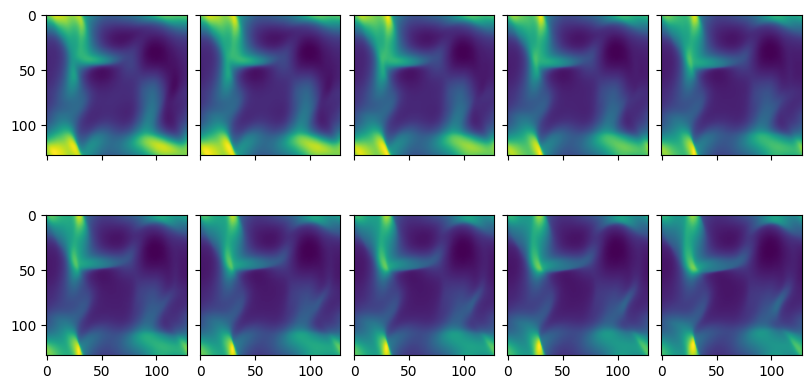

In [33]:
sample_idx = 20
fig, axes = plt.subplots(
    2, 5, figsize=(8, 4), constrained_layout=True, sharex=True, sharey=True
)
for i, ax in enumerate(axes.flat):
    ax.imshow(batch[sample_idx, i, 0])

In [34]:
batch.shape

(64, 31, 4, 128, 128)

In [35]:
len(source)

71000

In [36]:
u_pred_dict = {}

traj_idx = 100
for model_type, path in tqdm(model_paths.items()):
    model = load_model(checkpoint_dir / model_type / "OneStepLoss" / path)
    model = eqx.nn.inference_mode(model, True)

    context, u_data = batch[:, :20], batch[:, 20:]
    u_pred = eqx.filter_vmap(
        lambda x, y: model.rollout(x, (0.015, 1 / 128,1/128), num_steps=len(y))[0]
    )(context, u_data)

    u_pred_dict[model_type] = u_pred

 50%|█████     | 1/2 [00:04<00:04,  4.67s/it]/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/nn/structured_linear.py:35: UserWarning: in_features is not divisible by num_blocks. Input vector will be 
                padded with zeros.
  warnings.warn(
/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/nn/structured_linear.py:40: UserWarning: out_features is not divisible by num_blocks. Output vector 
            will be truncated to the requested size.
  warnings.warn("""out_features is not divisible by num_blocks. Output vector
100%|██████████| 2/2 [00:16<00:00,  8.06s/it]


In [37]:
u_pred_dict["DPOT"].shape

(64, 11, 4, 128, 128)

In [38]:
from einops import reduce


reduce(u_data**2, "B T C X Y -> C", reduction="mean")

array([1.2067342 , 1.2067342 , 1.2067342 , 0.26862356], dtype=float32)

In [39]:
u_data.shape

(64, 11, 4, 128, 128)

Text(0.5, 0.98, 'Rollout=1 step(s)')

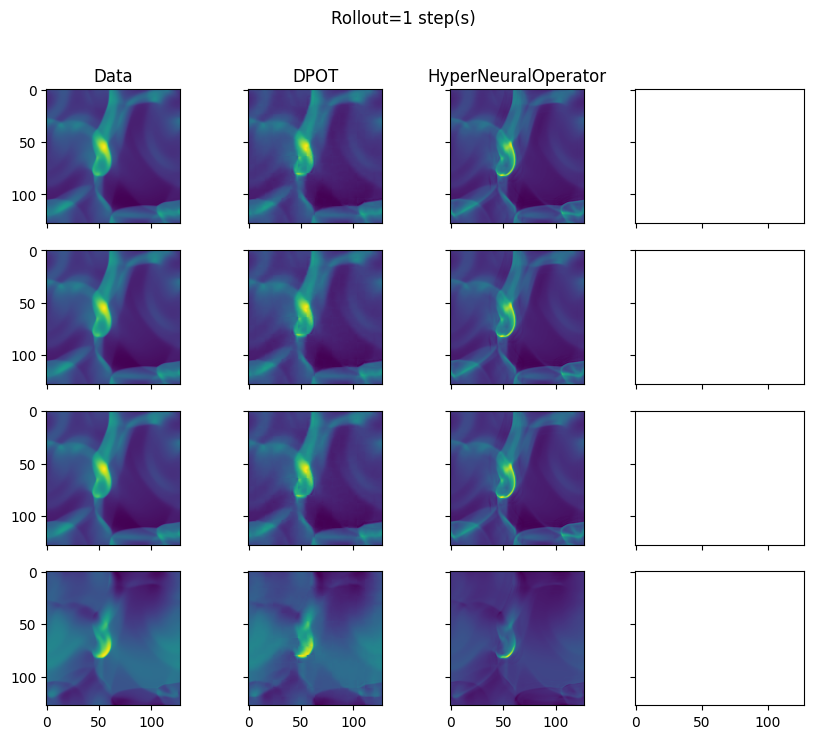

In [42]:
t_idx =0
sample_idx = 10
fig, axes = plt.subplots(4, 4, figsize=(10, 8), sharex=True, sharey=True)
axes[0, 0].set_title("Data")
for j in range(4):
    axes[j, 0].imshow(u_data[sample_idx, t_idx, j])
    for i, (model_name, u_pred) in enumerate(u_pred_dict.items()):
        axes[0, i + 1].set_title(model_name)
        axes[j, i + 1].imshow(u_pred[sample_idx, t_idx, j])
fig.suptitle(f"Rollout={t_idx + 1} step(s)")

In [29]:
import jax.numpy as jnp
from context_flux_no.metrics import relative_L2_error


jax.tree.map(
    lambda x: jnp.mean(eqx.filter_vmap(relative_L2_error)(x[:,], u_data[:,])),
    u_pred_dict,
)

{'DISCO': Array(0.3890891, dtype=float32),
 'DPOT': Array(0.40279436, dtype=float32),
 'HyperNeuralOperator': Array(0.44079953, dtype=float32)}